# 🟢 미션 1 (필수) — 내 문장이 12층을 지나가는 것을 본다

오늘 우리는 블록 하나를 만들었고, 그것이 BERT 한 층과 같다는 걸 확인했다.
이제 **내 문장**을 그 12층에 통과시켜 무슨 일이 일어나는지 본다.

## 낼 것

1. **막대그래프 1장** — 내 문장이 층을 지나며 얼마나 바뀌었나 (제목에 내 문장이 들어간다)
2. 두 줄 — 아래 제출 칸의 ①②

In [4]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent if Path.cwd().name == "missions" else Path.cwd()))

import matplotlib.pyplot as plt
import torch

import block
import koplot

koplot.use_korean()

[koplot] 한글 폰트 적용: NanumGothic


'NanumGothic'

## 1. 내 문장을 넣는다

✍️ **아래 문장을 자기 문장으로 바꾼다.** 너무 길지 않게 (10~20 글자).

In [5]:
내문장 = "오늘 배운 트랜스포머 블록은 열두 층이 반복된다."     # ✍️ 바꾼다

In [6]:
from transformers import AutoTokenizer

토크나이저 = AutoTokenizer.from_pretrained(block.BERT_ID)
모델 = block.load_bert()

입력 = 토크나이저(내문장, return_tensors="pt")
토큰들 = 토크나이저.convert_ids_to_tokens(입력["input_ids"][0])

print("내 문장:", 내문장)
print("토큰 수:", len(토큰들))
print("토큰들 :", 토큰들)

/home/student/llm-practice/c2-transformer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 403.56it/s]

내 문장: 오늘 배운 트랜스포머 블록은 열두 층이 반복된다.
토큰 수: 17
토큰들 : ['[CLS]', '오늘', '배운', '트랜스', '##포', '##머', '블록', '##은', '열', '##두', '층', '##이', '반복', '##된', '##다', '.', '[SEP]']


`[CLS]` 와 `[SEP]` 은 문장의 시작·끝을 알리는 특수 토큰이다. `##` 이 붙은 것은
**앞 토큰에 이어지는 조각**이라는 뜻이다 (내일 자세히 본다).

## 2. 12층을 지나가는 것을 전부 꺼낸다

`output_hidden_states=True` 를 주면 **각 층을 지난 뒤의 값**을 전부 돌려준다.

In [7]:
with torch.no_grad():
    결과 = 모델(**입력, output_hidden_states=True)

층별 = 결과.hidden_states
print("돌려받은 개수:", len(층별))
print()
for i, h in enumerate(층별):
    이름 = "입력 (층을 지나기 전)" if i == 0 else f"{i}층 통과 후"
    print(f"  [{i:>2d}] {tuple(h.shape)}   {이름}")

돌려받은 개수: 13

  [ 0] (1, 17, 768)   입력 (층을 지나기 전)
  [ 1] (1, 17, 768)   1층 통과 후
  [ 2] (1, 17, 768)   2층 통과 후
  [ 3] (1, 17, 768)   3층 통과 후
  [ 4] (1, 17, 768)   4층 통과 후
  [ 5] (1, 17, 768)   5층 통과 후
  [ 6] (1, 17, 768)   6층 통과 후
  [ 7] (1, 17, 768)   7층 통과 후
  [ 8] (1, 17, 768)   8층 통과 후
  [ 9] (1, 17, 768)   9층 통과 후
  [10] (1, 17, 768)   10층 통과 후
  [11] (1, 17, 768)   11층 통과 후
  [12] (1, 17, 768)   12층 통과 후


**개수가 층 수보다 하나 많다.** 맨 앞이 아직 아무 층도 안 지난 입력이기 때문이다.

**모양이 전부 같다.** `(1, 토큰수, 768)` — 블록이 들어간 모양 그대로 내보내기 때문이다.
오늘 `## 6` 에서 확인한 그 성질이다.

## 3. 층을 지날수록 얼마나 바뀌나

바로 앞 층과 얼마나 달라졌는지를 잰다. **1에 가까우면 거의 안 바뀐 것**이고,
작을수록 많이 바뀐 것이다.

In [8]:
import torch.nn.functional as F

변화 = []
for i in range(1, len(층별)):
    앞, 뒤 = 층별[i - 1][0], 층별[i][0]
    유사도 = F.cosine_similarity(앞, 뒤, dim=-1).mean().item()
    변화.append(유사도)

print(f"{'층':>4s} {'앞 층과 얼마나 비슷한가':>22s}")
print("-" * 30)
for i, v in enumerate(변화, start=1):
    막대 = "█" * int(v * 20)
    print(f"{i:>4d} {v:>22.4f}  {막대}")

가장변한층 = 변화.index(min(변화)) + 1
print(f"\n가장 많이 바뀐 층: {가장변한층}층 (유사도 {min(변화):.4f})")

   층          앞 층과 얼마나 비슷한가
------------------------------
   1                 0.8863  █████████████████
   2                 0.9307  ██████████████████
   3                 0.9354  ██████████████████
   4                 0.9158  ██████████████████
   5                 0.9287  ██████████████████
   6                 0.9509  ███████████████████
   7                 0.9434  ██████████████████
   8                 0.9453  ██████████████████
   9                 0.8911  █████████████████
  10                 0.8890  █████████████████
  11                 0.9237  ██████████████████
  12                 0.8355  ████████████████

가장 많이 바뀐 층: 12층 (유사도 0.8355)


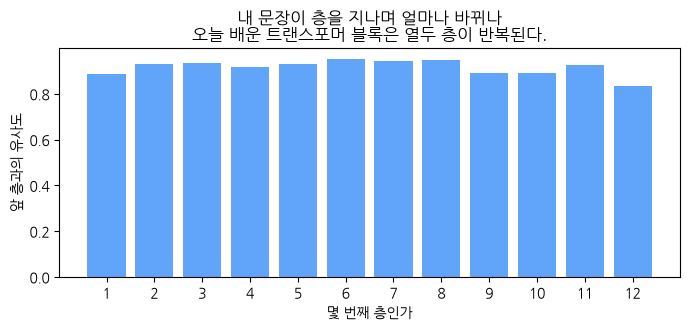

In [9]:
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.bar(range(1, len(변화) + 1), 변화, color="#60a5fa")
ax.set_xlabel("몇 번째 층인가")
ax.set_ylabel("앞 층과의 유사도")
ax.set_title(f"내 문장이 층을 지나며 얼마나 바뀌나\n{내문장}")
ax.set_xticks(range(1, len(변화) + 1))
plt.tight_layout()
plt.show()

## ✍️ 제출 — 두 가지를 적는다

> ① 층별 모양은 ____ 로 전부 같았다.
> ② 변화가 큰 구간은 ____ 였고, 완만한 구간은 ____ 였다.

> ⚠️ **값은 사람마다 다르다.** 문장이 다르니 당연하다. 옆 사람과 숫자가 달라도 틀린 게 아니다.
> 봐야 할 것은 **곡선의 모양**이다.

## 더 해 보고 싶다면

`내문장` 을 아주 다른 문장으로 바꿔 다시 돌려 보라 — 짧은 문장, 뜻이 없는 문장,
외래어가 많은 문장. **모양이 얼마나 비슷한지** 보는 것이 재미있다.